## Planning Algorithms in AI 
## PS2: Sampling-based Planning

Student: Olga Tiupina

Problem: find path for 4-joints manipulator.

Solution: c++ library using binding for python to create a fast rrt search for the manipulator.

## Task I: Visualization

In [1]:
import numpy as np
import pickle
from environment import State, ManipulatorEnv
import rtt_planning_lib
import matplotlib.pyplot as plt

### Tools for visualization

In [2]:
def visualize_state(env, state, title="State"):
    env.state = state
    plt.figure(figsize=(6, 6))
    env.render(plt_show=False)
    plt.title(title)
    plt.show()


def visualize_states_single_plot(env, states, colors=None, title="All States"):
    """
    All states in the single canvas
    
    """
    plt.figure(figsize=(10, 10))
    original_state = env.state
    if colors is None:
        colors = plt.cm.rainbow(np.linspace(0, 1, len(states)))
    for i, state in enumerate(states):
        env.state = state
        joints = state.joints
        color = colors[i] if i < len(colors) else 'blue'
        for j in range(4):
            segment = joints[[j, j+1], :]
            alpha = 0.7 if i == len(states)-1 else 0.3 
            plt.plot(segment[:, 0], segment[:, 1], 'o-', 
                    color=color, alpha=alpha, linewidth=2)
    for obs in env._obstacles:
        plt.gca().add_patch(
            plt.Circle((obs[0], obs[1]), obs[2], fill=True, alpha=0.5))
    env.state = original_state
    
    plt.axis('equal')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


def make_manipulator_gif(env, state_list, gif_name="solve_4R.gif"):
    import matplotlib.animation as animation
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    def update(frame):
        ax.clear()
        env.state = state_list[frame]
        env.render(plt_show=False)
        ax.set_title(f"Step {frame+1}/{len(state_list)}")
        return []
    
    anim = animation.FuncAnimation(fig, update, frames=len(state_list), interval=300, blit=False)
    anim.save(gif_name, writer='pillow')
    plt.close()



### A

In [3]:
with open("data.pickle", "rb") as f:
    data = pickle.load(f)

start_state = State(np.array(data["start_state"]))
goal_state = State(np.array(data["goal_state"]))

env = ManipulatorEnv(
    obstacles=np.array(data["obstacles"]),
    initial_state=start_state,
    collision_threshold=data["collision_threshold"]
)

print("Start state angles:", start_state.angles)
print("Start state joints:")
print(start_state.joints)
print("Goal state angles:", goal_state.angles)
print("Goal state joints:")
print(goal_state.joints)


Start state angles: [0. 0. 0. 0.]
Start state joints:
[[0. 0.]
 [1. 0.]
 [2. 0.]
 [3. 0.]
 [4. 0.]]
Goal state angles: [-180.  -60.   72.  -60.]
Goal state joints:
[[ 0.00000000e+00  0.00000000e+00]
 [-1.00000000e+00 -1.22464680e-16]
 [-1.50000000e+00  8.66025404e-01]
 [-2.47814760e+00  6.58113713e-01]
 [-3.14727821e+00  1.40125854e+00]]


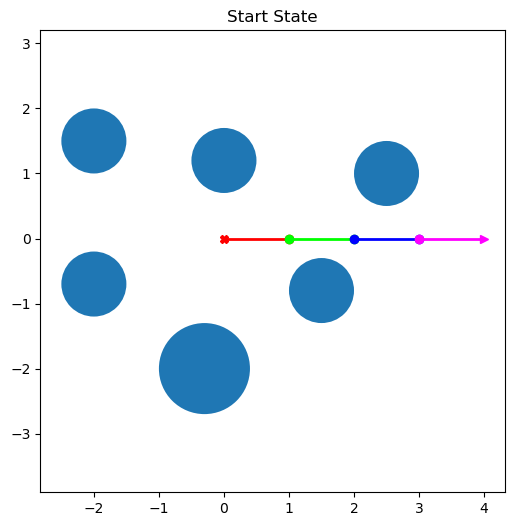

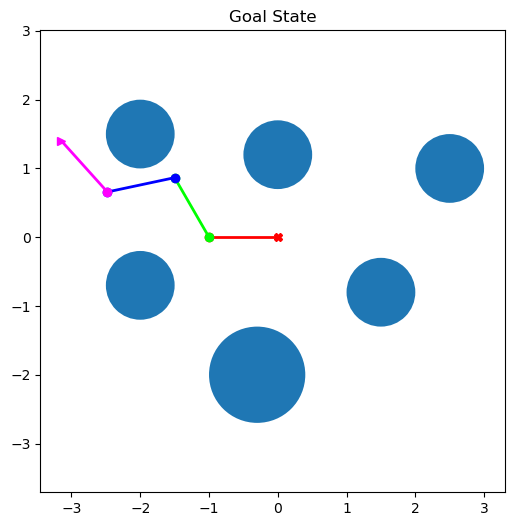

In [4]:
visualize_state(env, start_state, "Start State")
visualize_state(env, goal_state, "Goal State")


In the previous PS1 task, the orientation space was discrete (0, 45, 90, 135).

In this task, it is continuous: (−180°, 180°], which leads to:

- an infinite configuration space,
- smoother and more realistic robot movements,
- the need to use continuous space search methods (RRT),
- more accurate collision checking.

This means the task becomes significantly more complex, but also closer to real robots.


### B

In [5]:
# prepare data for c++ lib
start_list = np.array(data["start_state"]).tolist()
goal_list = np.array(data["goal_state"]).tolist()
obstacles_list = np.array(data["obstacles"]).tolist()

In [6]:
planner = rtt_planning_lib.RRT(obstacles_list)
planner.set_start_goal(start_list, goal_list)

RRT has been created


In [7]:
random_states = []
collisions_list = []
for i in range(4):
    angles = planner.sample()
    state = State(np.array(angles))
    while i % 2 == 0 and planner.check_collision(angles):
        angles = planner.sample()
        state = State(np.array(angles))
    while i % 2 != 0 and not planner.check_collision(angles):
        angles = planner.sample()
        state = State(np.array(angles))
    print(planner.check_collision(angles))
    random_states.append(state)

False
True
False
True



=== Random state 1 ===
Angles: [-180.  -60.   72.  -60.]
Collision: False


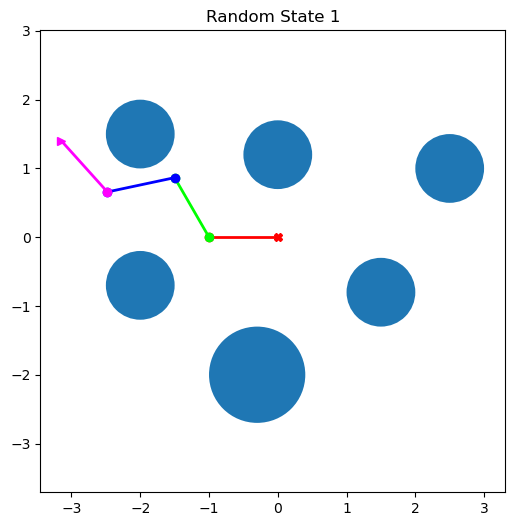


=== Random state 2 ===
Angles: [ 105.1320713  -147.24100306   25.85420568  -22.65070709]
Collision: True


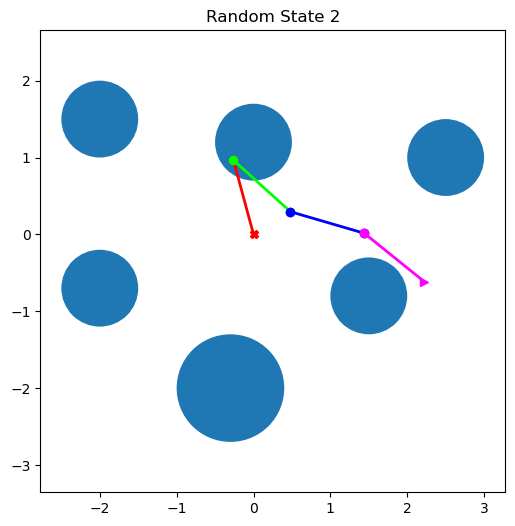


=== Random state 3 ===
Angles: [  29.52729105 -116.37086198 -141.87416123   25.13297349]
Collision: False


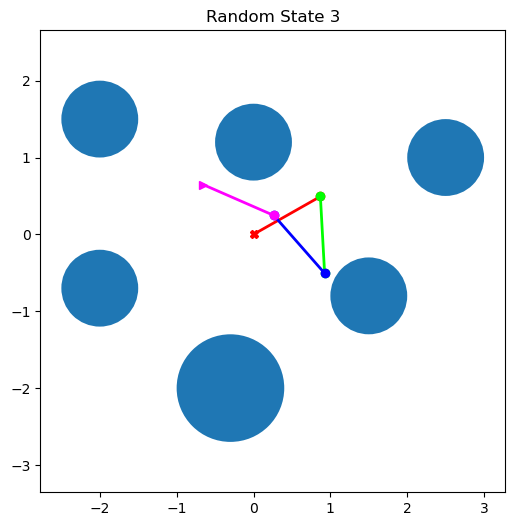


=== Random state 4 ===
Angles: [ -17.78689924 -159.30010078    5.85660412  -19.71203254]
Collision: True


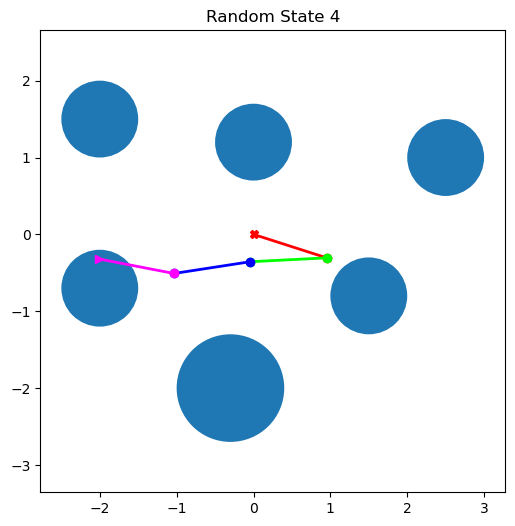

In [8]:
for i, st in enumerate(random_states, 1):
    print(f"\n=== Random state {i} ===")
    print("Angles:", st.angles)
    
    collision = env.check_collision(st)
    print("Collision:", collision)
    
    visualize_state(env, st, f"Random State {i}")


- Some random configurations lead to collisions when links get closer than the collision_threshold to an obstacle.
- The check_collision() and planner.check_collision(angles) from my library functions give the same results for the same angles, correctly detect collisions.
- Intersection of links among themselves is allowed, as can be seen in the images.
- The manipulator geometry follows sequential SE(2) multiplication, and angle changes are clearly visible.


## Task II: Rapidly-exploring Random Trees (RRT)

### A. Implement a collision check between any two configurations

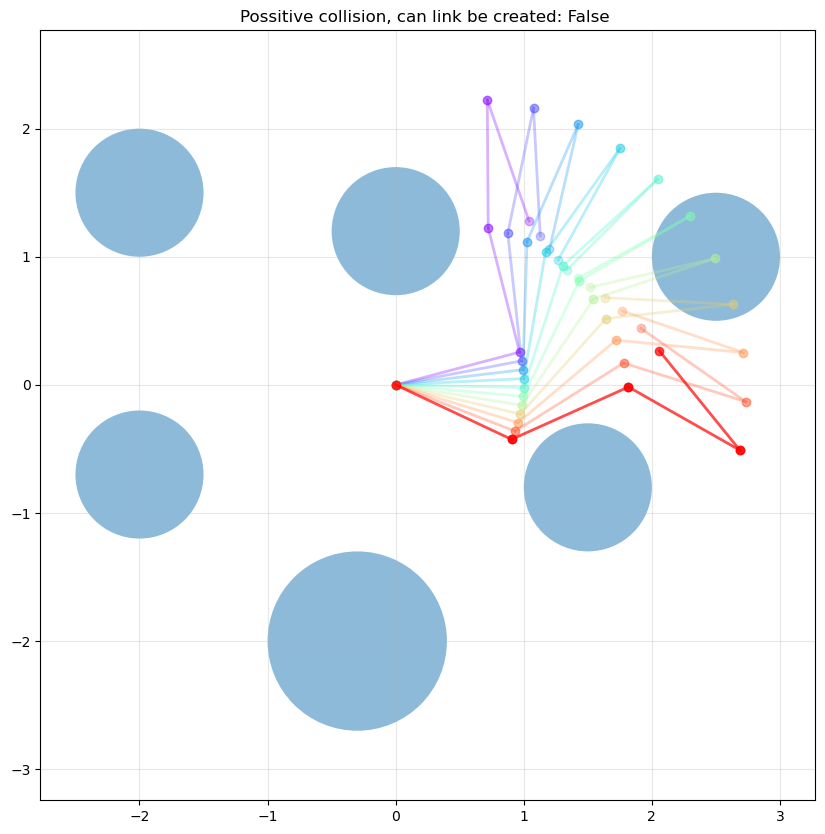

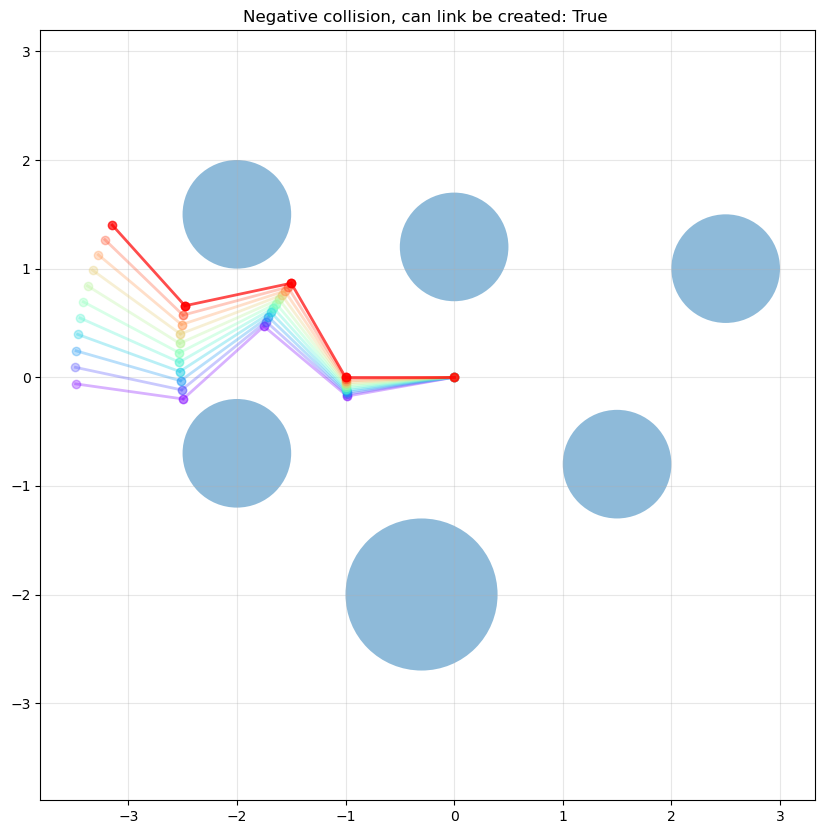

In [28]:
possitive_collision_angle = [-25.191662580041218, 49.35175183298484, -53.74820207208242, 158.60602284931153]
delta_possitive = 40
possitive_second_angle = [(angle + delta_possitive) % (360) for angle in possitive_collision_angle]
possitive_angles_list = planner.generate_states_btw(possitive_collision_angle, possitive_second_angle)
possitive_states_btw = []

for i, angles in enumerate(possitive_angles_list):
    state = State(np.array(angles))
    possitive_states_btw.append(state)
visualize_states_single_plot(env, possitive_states_btw, title = f"Possitive collision, can link be created: {planner.check_states_btw(possitive_collision_angle, possitive_second_angle)} ")


negative_collision_angle = [-180.0, -60.0, 72.0, -60.0]
delta_negative = 10
negative_second_angle = [(angle + delta_negative) % (360) for angle in negative_collision_angle]
negative_angles_list = planner.generate_states_btw(negative_collision_angle, negative_second_angle)

negative_states_btw = []

for i, angles in enumerate(negative_angles_list):
    state = State(np.array(angles))
    negative_states_btw.append(state)
visualize_states_single_plot(env, negative_states_btw, title = f"Negative collision, can link be created: {planner.check_states_btw(negative_collision_angle, negative_second_angle)} ")


The check_states_btw function checks whether a connection can be created between two states and returns True if the connection between the two nodes can be created and there are no collisions.

I chose a division check, specifying the angle step by dividing angle difference from given set in 10 steps increments. The function finds the difference in angles between pos1 and pos2 for each manipulator joint and divides it by 10 degrees. In the task we have suggestion: take angle step not more than 10. For difference equals to 10 the function will look at step <= 10 / 10 = 1 degree. I think it's enough distance to find collisions precisely. In the final task, it's necessary to consider larger and smaller angles. For larger angles I considered 15 and 25. In both cases I'll get very good degree step size from my fuction: 1.5 and 2 degree.

### B: RRT algorithm

Find the path!
Iteration: 4368
Plan length: 63


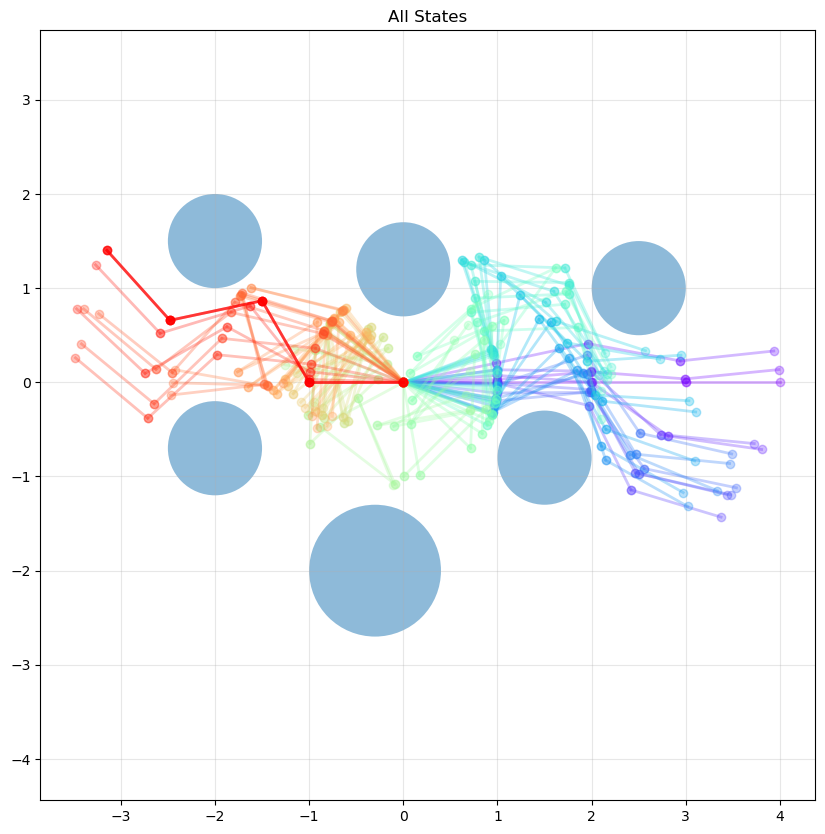

In [11]:
if planner.launch():
    plann_list = planner.get_plan()
    state_list = []
    for i, angles in enumerate(plann_list):
        state = State(np.array(angles))
        state_list.append(state)
    visualize_states_single_plot(env, state_list)
    # make_manipulator_gif(env, state_list, "solve_4R.gif")

### C
Non-optimality planner. Also I've added probability to get final state in RRT: 5%. Iteration amount from 300 to more than 500 000. I have iteration bound equall to 500 000 to stop the algorithm.

Some outputs with probability 5%:

Iteration: 3924
Plan length: 58

Iteration: 5039
Plan length: 69

Iteration: 62323
Plan length: 64

Iteration: 8016
Plan length: 50

Some outputs without probability:

Iteration: 17562
Plan length: 63

long-long time withot results...

### D

Find the path!
Iteration: 9783
Plan length: 58


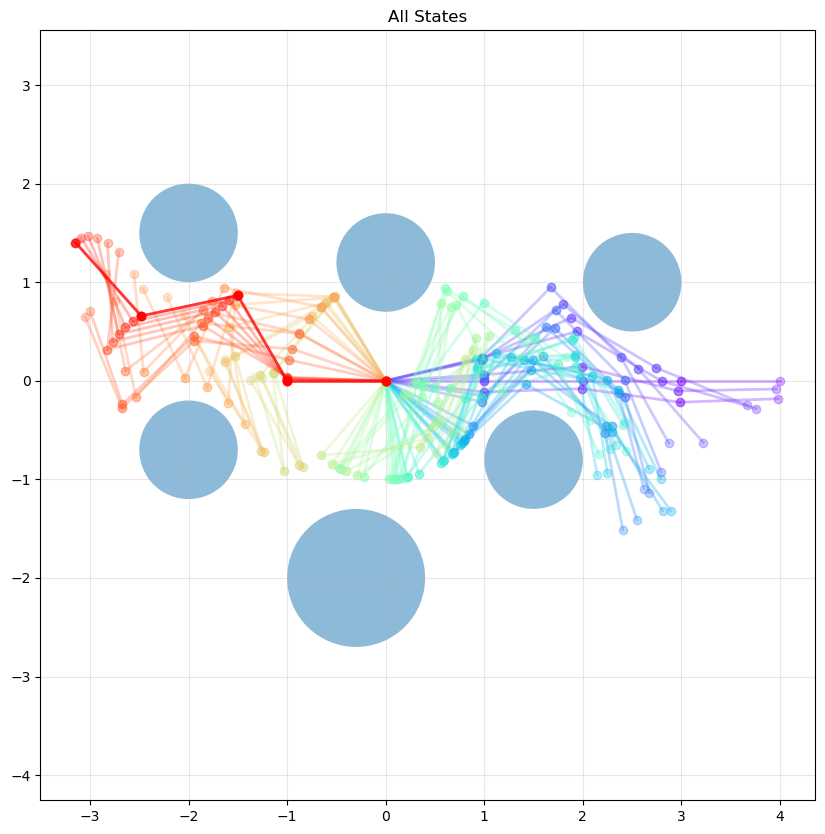

In [12]:
planner.set_weights_in_distant_func(0.2, 1.0, 1.0, 1.0)
if planner.launch():
    plann_list = planner.get_plan()
    state_list = []
    for i, angles in enumerate(plann_list):
        state = State(np.array(angles))
        state_list.append(state)
    visualize_states_single_plot(env, state_list)

With lower weight of nearer to base joints a little bit shorter distance is got:

weights: 0.4, 0.6, 0.8, 1.0
Iteration: 2308
Plan length: 51

weights: 0.2, 1.0, 1.0, 1.0
Iteration: 5036
Plan length: 46


### E

Find the path!
Iteration: 17907
Plan length: 121


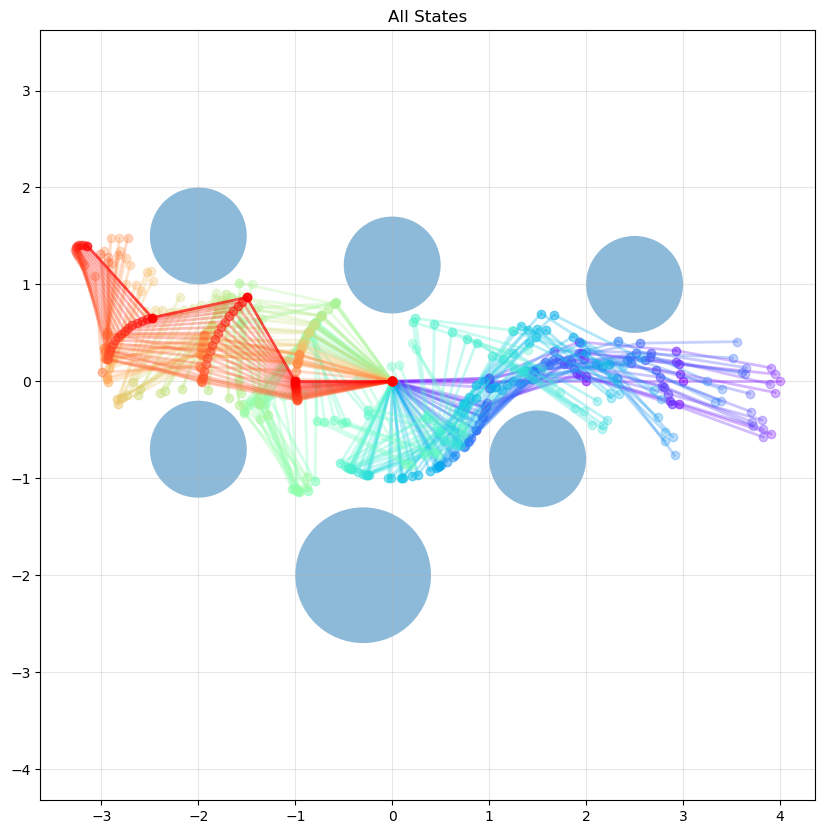

In [13]:
planner.set_weights_in_distant_func(1.0, 1.0, 1.0, 1.0)
planner.set_step_threshold(5)
if planner.launch():
    plann_list = planner.get_plan()
    state_list = []
    for i, angles in enumerate(plann_list):
        state = State(np.array(angles))
        state_list.append(state)
    visualize_states_single_plot(env, state_list)
    # make_manipulator_gif(env, state_list, "solve_4R_5.gif")

    

With lower step like 5 degree a longer path and bigger overall iterations amout were got:

Iteration: 10858
Plan length: 114

Iteration: 7603
Plan length: 119

It connects to lower research enviroment speed.

Find the path!
Iteration: 1965
Plan length: 39


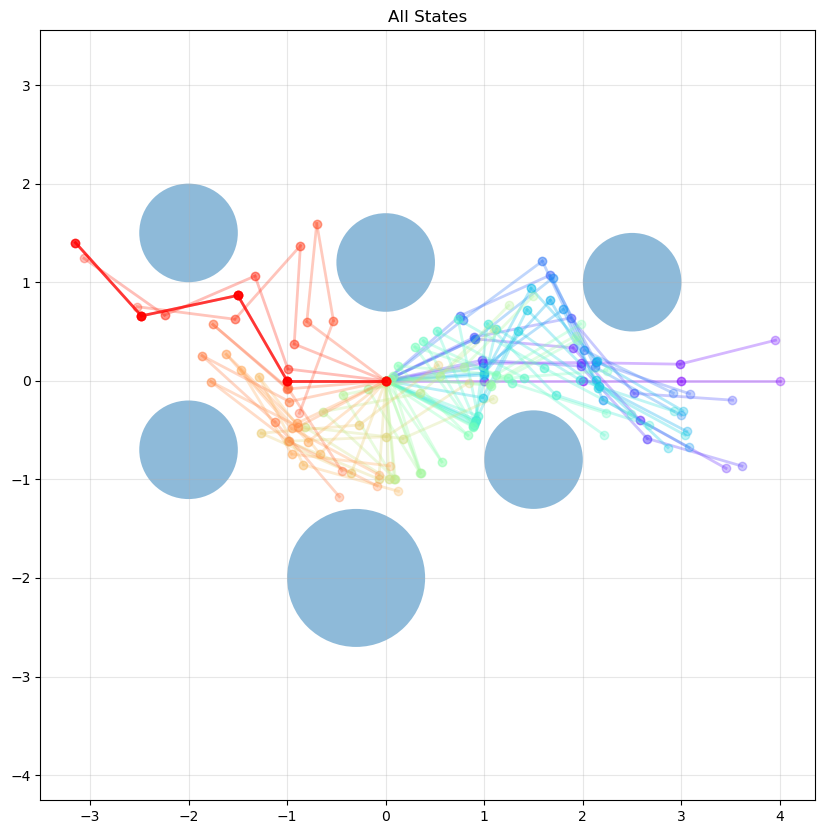

In [14]:
planner.set_weights_in_distant_func(1.0, 1.0, 1.0, 1.0)
planner.set_step_threshold(15)
if planner.launch():
    plann_list = planner.get_plan()
    state_list = []
    for i, angles in enumerate(plann_list):
        state = State(np.array(angles))
        state_list.append(state)
    visualize_states_single_plot(env, state_list)
    # make_manipulator_gif(env, state_list, "solve_4R_15.gif")


With bigger step like 15 degree a shorter path and smaller overall iterations amout were got:

Iteration: 2149
Plan length: 37

Iteration: 924
Plan length: 31

for 25:
Iteration: 781
Plan length: 29

It connects to bigger research enviroment speed.